# 05 · Statistical Critique of Threshold Tuning
**Process-model step:** *Evaluate* · **Concept:** limits of the Chapter 9 methodology · **Statistics:** selection bias, base rates, ROC vs precision-recall, hypothesis tests, bootstrap, multiple comparisons, regression to the mean, target shuffling (*Practical Statistics* ch. 2–3, 5)

Notebook 04 showed *how* thresholds are tuned. This one asks **how far the evidence behind a tuned threshold can be trusted**. Each experiment isolates one weakness — the same ones you can cite in a written critique:

| # | Weakness of "tune to historical STRs" | Statistical concept | Experiment |
|---|---|---|---|
| E1 | **Circularity** – history was produced by the old thresholds | selection bias, inherited bias | §1 |
| E2 | **Overfitting to known typologies** | non-representative training set | §2 |
| E3 | **Base-rate neglect** – precision is judged without prevalence | Bayes, ROC vs PR | §3 |
| E4 | **Alerted customers are a biased sample** | Berkson / range restriction, reject inference | §4 |
| E5 | **Is a productivity gain real?** | cluster bootstrap, Fisher exact test | §5 |
| E6 | **Many thresholds tried, best one picked** | multiple comparisons, winner's curse, regression to the mean, target shuffling | §6 |
| E7 | **False negatives are invisible** | sampling non-alerted customers, rule of three | §7 |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

txn = pd.read_pickle(ak.PROC / "txn_clean.pkl")
kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl")
feat = pd.read_pickle(ak.PROC / "features.pkl")
truth = ak.load_truth()                                    # ORACLE - what a real bank never has
n = len(kyc)
seg_of = kyc.set_index("customer_id").segment
PROD = dict(min_single=2500, min_count=3, min_agg=10_000, lookback=5, cooldown=30)
N_LAUND = int(truth.is_launderer.sum())

def run_alerts(params=None, segment_params=None):
    params = {**PROD, **(params or {})}
    if segment_params is None:
        a = ak.run_scenario(txn, n, **params)
    else:
        parts = [ak.run_scenario(txn[txn.customer_id.isin(seg_of.index[seg_of == s])], n, **{**PROD, **p}) for s, p in segment_params.items()]
        a = pd.concat(parts, ignore_index=True); a["alert_id"] = np.arange(1, len(a) + 1)
    a = ak.simulate_dispositions(a, truth); a["segment"] = a.customer_id.map(seg_of)
    return a

def true_recall(a):
    return a.customer_id.isin(truth.customer_id[truth.is_launderer == 1]).groupby(a.customer_id).max().sum() / N_LAUND

prod = run_alerts()
print(f"production: {len(prod)} alerts, {prod.str_filed.sum()} STR alerts, true customer recall (oracle) = {true_recall(prod):.1%}")

production: 1255 alerts, 271 STR alerts, true customer recall (oracle) = 59.3%


## 1 · E1 — Circularity: history can only validate the thresholds that produced it
*"Set the threshold so the scenario covers every customer for whom an STR was filed"* (one of the book's 'relatively simple ways'). Suppose the bank had launched with a **different** initial threshold. Run the method under five historical regimes:

In [2]:
rows = []
for A0 in [8000, 10_000, 15_000, 20_000, 30_000]:
    hist = run_alerts({"min_agg": A0})
    str_hist = hist[hist.str_filed == 1]
    A_star = str_hist.agg_amt.min()                                   # lowest A that still covers every STR in the history
    lau = hist.customer_id.isin(truth.customer_id[truth.is_launderer == 1]).groupby(hist.customer_id).max().sum()
    rows.append(dict(historical_threshold=A0, STR_customers=str_hist.customer_id.nunique(), derived_threshold=A_star,
                     apparent_recall_vs_STR_history=1.0, TRUE_recall_oracle=lau / N_LAUND))
circ = pd.DataFrame(rows); circ

,historical_threshold,STR_customers,derived_threshold,apparent_recall_vs_STR_history,TRUE_recall_oracle
0,8000,84,"8,533.190",1.000,0.602
1,10000,83,"10,015.310",1.000,0.593
2,15000,75,"15,208.980",1.000,0.553
3,20000,67,"20,068.210",1.000,0.504
4,30000,55,"30,153.910",1.000,0.439


The method "derives" whatever threshold the bank **already had**, always reports 100 % coverage, and never signals that true coverage differs by regime. It can only look **upwards** from the current threshold: below it no alerts exist, hence no STRs. *Statistical name:* the sampling mechanism depends on the parameter being estimated — a non-ignorable selection mechanism. **Fix:** below-the-line sampling or random sampling of non-alerted customers (§7).

## 2 · E2 — Overfitting to known typologies
Which behaviours appear in the STR history, compared with what launderers actually do?

In [3]:
al = prod.merge(truth[["customer_id", "typology"]], on="customer_id")
str_cust = al[al.str_filed == 1].drop_duplicates("customer_id")
mix = pd.DataFrame({"share of STR-history customers": str_cust.typology.value_counts(normalize=True),
                    "share of true launderers": truth[truth.is_launderer == 1].typology.value_counts(normalize=True)}).fillna(0)
alerted = truth.assign(alerted=truth.customer_id.isin(prod.customer_id))
mix["customer recall of this scenario"] = alerted[alerted.is_launderer == 1].groupby("typology").alerted.mean()
mix.loc["none"] = [str_cust.typology.eq("none").mean(), np.nan, np.nan]        # defensive / false STRs
mix

,share of STR-history customers,share of true launderers,customer recall of this scenario
typology,,,
commingling,0.072,0.114,0.500
mule_ring,0.096,0.187,0.348
none,0.145,NaN,NaN
pass_through,0.048,0.154,0.263
smurfing_low,0.072,0.163,0.300
structuring,0.566,0.382,1.000


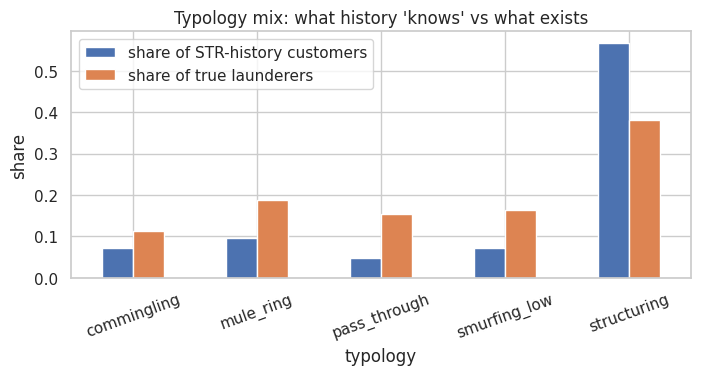

In [4]:
mix.drop("none")[["share of STR-history customers", "share of true launderers"]].plot.bar(figsize=(8, 3.2))
plt.title("Typology mix: what history 'knows' vs what exists"); plt.ylabel("share"); plt.xticks(rotation=20); plt.show()

Tuning on STR history teaches the scenario the typology it already catches (structuring); everything else is **invisible by construction**. A cash-based scenario can never find wire pass-through or mule rings — *scenario coverage* (book ch. 6) must be assessed across the whole scenario library, and new typologies need dedicated rules or the models of notebooks 03, 06, 07.

## 3 · E3 — Base rates: precision without prevalence is meaningless
### 3.1 Bayes on the production rule (customer level)

rule sensitivity = 0.59, specificity = 0.910, PPV at lab prevalence (3.5%) = 19.4%


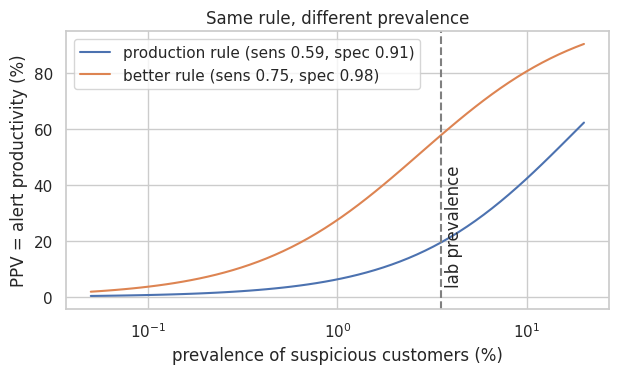

In [5]:
al_ids = set(prod.customer_id)
is_l = truth.set_index("customer_id").is_launderer
sens = is_l[list(al_ids)].sum() / is_l.sum()
spec = 1 - is_l.index.isin(al_ids)[is_l.values == 0].mean()
print(f"rule sensitivity = {sens:.2f}, specificity = {spec:.3f}, PPV at lab prevalence ({is_l.mean():.1%}) = "
      f"{sens * is_l.mean() / (sens * is_l.mean() + (1 - spec) * (1 - is_l.mean())):.1%}")

prev = np.logspace(-3.3, -0.7, 60)
ppv = lambda se, sp: se * prev / (se * prev + (1 - sp) * (1 - prev))
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(prev * 100, ppv(sens, spec) * 100, label=f"production rule (sens {sens:.2f}, spec {spec:.2f})")
ax.plot(prev * 100, ppv(0.75, 0.98) * 100, label="better rule (sens 0.75, spec 0.98)")
ax.axvline(is_l.mean() * 100, ls="--", c="grey"); ax.text(is_l.mean() * 100 * 1.05, 5, "lab prevalence", rotation=90)
ax.set(xscale="log", xlabel="prevalence of suspicious customers (%)", ylabel="PPV = alert productivity (%)", title="Same rule, different prevalence")
ax.legend(); plt.show()

At the 0.1–0.5 % prevalence typical of real portfolios the *same* rule's productivity is several times lower than in this lab — so a productivity target has to be set **per segment and prevalence**, not copied from another bank.

### 3.2 ROC is prevalence-blind, precision-recall is not
Score customers with a simple additive risk score; vary prevalence by sub-sampling positives or negatives.

In [6]:
zc = ["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "hr_share"]
score = sum((feat[c] - feat[c].mean()) / feat[c].std() for c in zc).values
y = feat.is_launderer.values
pos, neg = np.flatnonzero(y == 1), np.flatnonzero(y == 0)
rng = np.random.default_rng(0)
rows = []
for p in [0.003, 0.01, 0.02, 0.035, 0.08, 0.2]:
    a, ap = [], []
    for _ in range(40):
        if p <= y.mean():   idx = np.r_[rng.choice(pos, int(round(p / (1 - p) * len(neg))), replace=False), neg]
        else:               idx = np.r_[pos, rng.choice(neg, int(round((1 - p) / p * len(pos))), replace=False)]
        a.append(roc_auc_score(y[idx], score[idx])); ap.append(average_precision_score(y[idx], score[idx]))
    rows.append(dict(prevalence=p, ROC_AUC=np.mean(a), avg_precision=np.mean(ap)))
pd.DataFrame(rows).set_index("prevalence")

,ROC_AUC,avg_precision
prevalence,,
0.003,0.917,0.459
0.010,0.917,0.531
0.020,0.914,0.570
0.035,0.917,0.619
0.080,0.917,0.698
0.200,0.918,0.811


AUC barely moves; average precision collapses as prevalence falls. For alert-queue design report **precision-recall** (or precision at the analysts' capacity), not just AUC (*Practical Statistics*: 'the rare class problem').

## 4 · E4 — Alerted customers are a biased sample
Everything the bank *labels* is drawn from customers the rules already selected. Compare relationships in the **whole** population with those seen among **alerted** customers only:

In [7]:
al_flag = feat.customer_id.isin(prod.customer_id).values
cols = ["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "hr_share", "log_n_counterparties", "night_share"]
auc = pd.DataFrame({"AUC, all customers": {c: roc_auc_score(y, feat[c]) for c in cols},
                    "AUC, alerted only": {c: roc_auc_score(y[al_flag], feat[c][al_flag]) for c in cols}})
auc["AUC drop"] = auc.iloc[:, 0] - auc.iloc[:, 1]; auc

,"AUC, all customers","AUC, alerted only",AUC drop
log_turnover_ratio,0.774,0.720,0.053
log_max_cash_agg_5d,0.857,0.781,0.077
near_ctr_cnt,0.771,0.840,-0.069
flowthrough_max,0.804,0.325,0.479
hr_share,0.660,0.378,0.282
log_n_counterparties,0.749,0.419,0.330
night_share,0.384,0.321,0.063


In [8]:
seg_rate = pd.DataFrame({"suspicious rate, all customers": feat.groupby("segment").is_launderer.mean(),
                         "suspicious rate, alerted only": feat[al_flag].groupby("segment").is_launderer.mean(),
                         "alerted customers": feat[al_flag].groupby("segment").size()}); seg_rate

,"suspicious rate, all customers","suspicious rate, alerted only",alerted customers
segment,,,
cash_intensive,0.115,0.119,201
corporate,0.040,0.200,25
retail_salaried,0.013,1.000,14
retail_self_employed,0.037,0.600,10
small_business,0.081,0.190,126


Selecting on the very variables that define suspicion (**range restriction / collider bias**) makes them look *less* predictive among alerted customers — some even **reverse sign** (AUC < 0.5: among alerted customers, high flow-through looks *safer*, because the ones who alerted without flow-through were the structurers) — and distorts segment risk. Now the consequence for a supervised model trained on alerted-only labels (the label 'STR ever filed'):

In [9]:
lab = prod.groupby("customer_id").str_filed.max()
tr = feat[al_flag].copy(); tr["y"] = tr.customer_id.map(lab)
X_cols = ["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "hr_share", "log_n_counterparties", "night_share", "cash_share_credits"]
rs = np.random.default_rng(1); msk = rs.random(len(tr)) < 0.7
sc = StandardScaler().fit(tr.loc[msk, X_cols])
lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(sc.transform(tr.loc[msk, X_cols]), tr.loc[msk, "y"])
auc_in = roc_auc_score(tr.loc[~msk, "y"], lr.predict_proba(sc.transform(tr.loc[~msk, X_cols]))[:, 1])
out = feat[~al_flag]
auc_out = roc_auc_score(out.is_launderer, lr.predict_proba(sc.transform(out[X_cols]))[:, 1])
print(f"trained on alerted customers | AUC on held-out alerted (label=STR): {auc_in:.3f} | AUC on NON-alerted customers (oracle label): {auc_out:.3f}")

sc_al = StandardScaler().fit(tr[X_cols]); lr_al = LogisticRegression(max_iter=1000, class_weight="balanced").fit(sc_al.transform(tr[X_cols]), tr.y)
sc_all = StandardScaler().fit(feat[X_cols]); lr_all = LogisticRegression(max_iter=1000, class_weight="balanced").fit(sc_all.transform(feat[X_cols]), feat.is_launderer)
pd.DataFrame({"coef: trained on alerted only (label = STR)": lr_al.coef_[0], "coef: trained on ALL customers (oracle label)": lr_all.coef_[0]}, index=X_cols)

trained on alerted customers | AUC on held-out alerted (label=STR): 0.861 | AUC on NON-alerted customers (oracle label): 0.865


,coef: trained on alerted only (label = STR),coef: trained on ALL customers (oracle label)
log_turnover_ratio,-0.081,0.794
log_max_cash_agg_5d,-0.081,-0.744
near_ctr_cnt,1.565,0.573
flowthrough_max,-0.698,-0.329
hr_share,0.456,0.522
log_n_counterparties,0.957,1.770
night_share,-0.566,-0.795
cash_share_credits,1.128,1.591


Honest reading: in this lab the ranking transfers reasonably to non-alerted customers (AUC above), because several features are informative outside the region the rule selects on. But the **coefficients differ materially** (e.g. `near_ctr_cnt` is weighted ≈ 2.7× more heavily, while `log_turnover_ratio` — a strong population-wide signal — gets almost none) — so the model's *explanations* and any threshold derived from it are distorted, and its AUC on non-alerted customers says nothing about how it performs on the few (≈ 1.6 %) missed cases at the top of the ranking. This is why notebook 06 treats **reject inference / random label sampling** as a first-class step.

## 5 · E5 — Is a productivity gain statistically real?
Compare production with two candidates. Alerts of the same customer are correlated, so bootstrap **customers (clusters)**, not alerts.

In [10]:
seg_cfg = {"retail_salaried": dict(min_single=1000, min_count=3, min_agg=5000), "retail_self_employed": dict(min_single=1000, min_count=3, min_agg=5000),
           "small_business": dict(min_single=1500, min_count=4, min_agg=12000), "cash_intensive": dict(min_single=1500, min_count=5, min_agg=20000),
           "corporate": dict(min_single=2500, min_count=3, min_agg=15000)}
cand = {"Raise A to 20k": run_alerts({"min_agg": 20_000}), "Per-segment balanced": run_alerts(segment_params=seg_cfg)}

def per_customer(a):
    g = a.groupby("customer_id").agg(al=("alert_id", "size"), st=("str_filed", "sum"))
    return g.reindex(range(n), fill_value=0)
P = per_customer(prod)

def cluster_bootstrap(c, B=2000, seed=0):
    r = np.random.default_rng(seed); C = per_customer(c)
    idx = r.integers(0, n, (B, n))
    sp, ap, sc_, ac = (P.st.values[idx].sum(1), P.al.values[idx].sum(1), C.st.values[idx].sum(1), C.al.values[idx].sum(1))
    d_prod = sc_ / ac - sp / ap; ret = sc_ / sp
    return pd.Series({"productivity gain (mean)": d_prod.mean(), "gain 95% CI low": np.quantile(d_prod, .025), "gain 95% CI high": np.quantile(d_prod, .975),
                      "STR retained (mean)": ret.mean(), "retained 95% CI low": np.quantile(ret, .025), "retained 95% CI high": np.quantile(ret, .975)})
pd.DataFrame({k: cluster_bootstrap(v) for k, v in cand.items()}).T

,productivity gain (mean),gain 95% CI low,gain 95% CI high,STR retained (mean),retained 95% CI low,retained 95% CI high
Raise A to 20k,0.117,0.086,0.149,0.856,0.780,0.922
Per-segment balanced,0.156,0.116,0.199,0.999,0.854,1.167


Both the *gain* and the *loss* have intervals — a threshold change is a trade between two **uncertain** quantities. Present both, not just the improved ratio. A classical test for one contrast (production alerts in $10–20k vs ≥ $20k):

In [11]:
lo = prod[(prod.agg_amt >= 10_000) & (prod.agg_amt < 20_000)].str_filed; hi = prod[prod.agg_amt >= 20_000].str_filed
tab = [[hi.sum(), len(hi) - hi.sum()], [lo.sum(), len(lo) - lo.sum()]]
odds, p = stats.fisher_exact(tab)
print(f"productivity: >=20k {hi.mean():.1%} (n={len(hi)}) vs 10-20k {lo.mean():.1%} (n={len(lo)}); odds ratio {odds:.1f}, Fisher exact p = {p:.1e}")
print("-> a statistically clear difference. But p-values say nothing about the alerts you never saw (E1, E7).")

productivity: >=20k 38.8% (n=518) vs 10-20k 9.5% (n=737); odds ratio 6.0, Fisher exact p = 2.6e-35
-> a statistically clear difference. But p-values say nothing about the alerts you never saw (E1, E7).


## 6 · E6 — Many thresholds tried, the best one picked (multiple comparisons)
Tuning means searching a *grid* of (A, N) values and choosing a winner. Winners are partly lucky: their in-sample productivity overstates what you will get next period (**regression to the mean / winner's curse**). Design: pick the best combination on **H1** (Jan–Jun) alerts; check it on **H2** (Jul–Dec). Then a **target-shuffling** test (*Practical Statistics* ch. 2): re-run the search on labels randomly permuted — how good does the "best" threshold look when labels carry *no* information?

In [12]:
base = ak.simulate_dispositions(ak.run_scenario(txn, n, min_single=2500, min_count=2, min_agg=5000), truth)
H1, H2 = base[base.alert_day < 182], base[base.alert_day >= 182]
combos = [(A, N) for A in range(5000, 45_001, 2500) for N in (2, 3, 4, 5, 6)]
mask = lambda d: np.array([((d.agg_amt >= A) & (d.n_trx >= N)).values for A, N in combos])
M1, M2 = mask(H1), mask(H2); y1, y2 = H1.str_filed.values, H2.str_filed.values
n1, n2 = M1.sum(1), M2.sum(1)
p1, p2 = (M1 @ y1) / np.maximum(n1, 1), (M2 @ y2) / np.maximum(n2, 1)
grid = pd.DataFrame(combos, columns=["A", "N"]).assign(n_H1=n1, prod_H1=p1, n_H2=n2, prod_H2=p2)

rows = []
rng = np.random.default_rng(0)
for min_n in (30, 100, 200):
    ok = n1 >= min_n
    k = np.argmax(np.where(ok, p1, -1))
    null_max = np.array([((M1 @ rng.permutation(y1)) / np.maximum(n1, 1))[ok].max() for _ in range(1000)])
    rows.append(dict(min_alerts_per_combo=min_n, combos_eligible=int(ok.sum()), best_combo=f"A={combos[k][0]:,}, N={combos[k][1]}",
                     H1_productivity_of_winner=p1[k], H2_productivity_of_same_combo=p2[k],
                     baseline_H1_all_alerts=y1.mean(), best_of_grid_under_SHUFFLED_labels=null_max.mean()))
pd.DataFrame(rows)

,min_alerts_per_combo,combos_eligible,best_combo,H1_productivity_of_winner,H2_productivity_of_same_combo,baseline_H1_all_alerts,best_of_grid_under_SHUFFLED_labels
0,30,33,"A=25,000, N=3",0.492,0.426,0.125,0.181
1,100,14,"A=15,000, N=3",0.360,0.381,0.125,0.149
2,200,6,"A=15,000, N=2",0.261,0.292,0.125,0.135


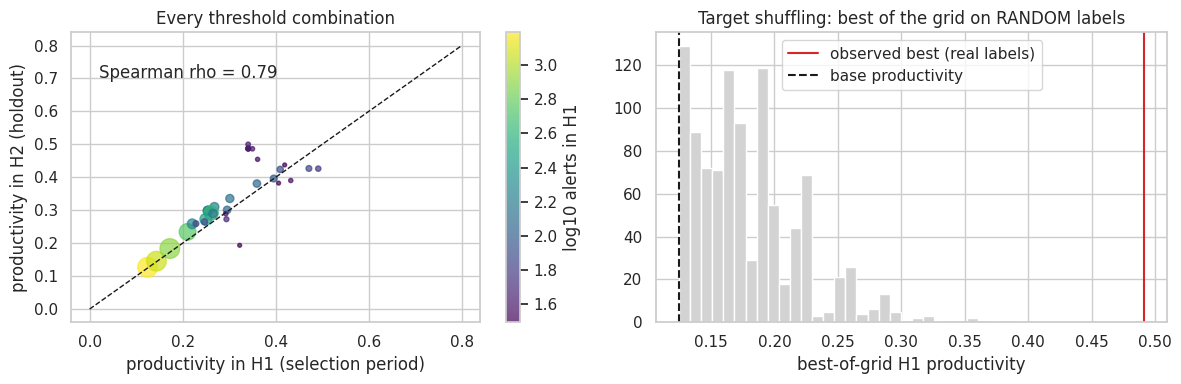

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ok = n1 >= 30
sc_ = ax[0].scatter(grid.prod_H1[ok], grid.prod_H2[ok], s=np.clip(grid.n_H1[ok] / 4, 5, 200), c=np.log10(grid.n_H1[ok]), cmap="viridis", alpha=.7)
ax[0].plot([0, .8], [0, .8], "k--", lw=1); plt.colorbar(sc_, ax=ax[0], label="log10 alerts in H1")
ax[0].set(xlabel="productivity in H1 (selection period)", ylabel="productivity in H2 (holdout)", title="Every threshold combination")
rho = stats.spearmanr(grid.prod_H1[ok], grid.prod_H2[ok])[0]; ax[0].text(.02, .7, f"Spearman rho = {rho:.2f}")
k = np.argmax(np.where(n1 >= 30, p1, -1))
null_max = np.array([((M1 @ rng.permutation(y1)) / np.maximum(n1, 1))[n1 >= 30].max() for _ in range(1000)])
ax[1].hist(null_max, bins=30, color="lightgrey"); ax[1].axvline(p1[k], color="tab:red", label="observed best (real labels)")
ax[1].axvline(y1.mean(), color="k", ls="--", label="base productivity")
ax[1].set(xlabel="best-of-grid H1 productivity", title="Target shuffling: best of the grid on RANDOM labels"); ax[1].legend()
plt.tight_layout(); plt.show()

Reading the results:
* With few alerts per combination, the winner is partly chosen on **noise**: on shuffled labels alone the "best" combination reaches ≈ 18 % productivity against a 12.5 % base rate — a purely spurious +5 points.
* The real signal here (structuring) is strong, so winners stay far above noise. But the small-sample winner **regresses** (H1 ≈ 49 % → H2 ≈ 43 %), while winners required to have ≥ 100 alerts hold up. Minimum sample size is the cheapest protection.
* **Rules of practice:** require a minimum alert count per candidate, evaluate winners on a **hold-out period**, report intervals, and count how many combinations you tried.

## 7 · E7 — Estimating false negatives: sample the non-alerted
Below-the-line tuning only looks just under today's threshold. A cleaner design: draw a **random sample of non-alerted customers**, have investigators review them, and estimate how many suspicious customers the system misses (with a confidence interval — *Practical Statistics* ch. 2 & the book's under-the-line analysis).

In [14]:
non_al = truth[~truth.customer_id.isin(prod.customer_id)].reset_index(drop=True)
true_fn, N_na = int(non_al.is_launderer.sum()), len(non_al)
print(f"non-alerted customers: {N_na:,} | truly suspicious among them (oracle): {true_fn}  = {true_fn / N_na:.2%}")

rows, r = [], np.random.default_rng(3)
for n_s in (100, 200, 400, 800):
    est, lo_, hi_, hit = [], [], [], 0
    for _ in range(1000):
        s = non_al.is_launderer.values[r.choice(N_na, n_s, replace=False)]
        k = s.sum(); lo, hi = ak.wilson_ci(k, n_s)
        est.append(k / n_s * N_na); lo_.append(lo * N_na); hi_.append(hi * N_na); hit += lo * N_na <= true_fn <= hi * N_na
    rows.append(dict(sample_size=n_s, mean_estimate_of_FN=np.mean(est), avg_CI_low=np.mean(lo_), avg_CI_high=np.mean(hi_),
                     zero_found_share=np.mean(np.array(est) == 0), CI_coverage=hit / 1000))
pd.DataFrame(rows).set_index("sample_size").assign(true_FN=true_fn)

non-alerted customers: 3,124 | truly suspicious among them (oracle): 50  = 1.60%


,mean_estimate_of_FN,avg_CI_low,avg_CI_high,zero_found_share,CI_coverage,true_FN
sample_size,,,,,,
100,49.047,14.624,195.412,0.195,0.978,50
200,50.250,19.130,138.350,0.036,0.965,50
400,49.008,23.448,103.353,0.001,0.973,50
800,50.890,30.020,86.204,0.000,0.968,50


In [15]:
print(f"Rule of three: if a review of 300 random non-alerted customers finds ZERO suspicious, the 95% upper bound on the prevalence is about 3/300 = {3/300:.1%}")
print("=> upper bound on missed customers ~", round(3 / 300 * N_na), "out of", N_na, " (a 'clean' sample is weaker evidence than it feels)")

Rule of three: if a review of 300 random non-alerted customers finds ZERO suspicious, the 95% upper bound on the prevalence is about 3/300 = 1.0%
=> upper bound on missed customers ~ 31 out of 3124  (a 'clean' sample is weaker evidence than it feels)


## 8 · Critique scorecard (adapt for your Week-12 capstone)

| Weakness | Evidence in this notebook | Statistical remedy | Practical remedy |
|---|---|---|---|
| Circular calibration to STR history (E1) | derived threshold always = historical threshold; 100 % 'recall' regardless of true recall | model the selection mechanism; use *un*selected data | random / stratified sampling of non-alerted; periodic below-the-line runs |
| Typology overfitting (E2) | STR mix dominated by one behaviour | stratify by typology, report per-typology recall | scenario-coverage matrix, complementary models (03, 06, 07) |
| Base-rate neglect (E3) | PPV collapses at real prevalence; AUC unchanged | Bayes, precision-recall, precision@capacity | set targets per segment |
| Biased labelled sample (E4) | features lose power among alerted; model fails on non-alerted | reject inference, inverse-probability weights, random label sample | investigate a random slice |
| Unquantified uncertainty (E5) | bootstrap CIs on gain **and** loss | cluster bootstrap, exact tests | report ranges |
| Garden of forking paths (E6) | shuffled labels give apparent gains; regression to the mean | hold-out period, minimum n, target shuffling, correction for #tests | freeze the protocol before looking |
| Invisible false negatives (E7) | FN estimate needs hundreds of reviews | sample-size planning, rule of three | fund a standing FN-sampling programme |

**Next → `06_predictive_analytics`**